# Medical Appointment No-Shows
### Python exploratory data analysis | Lamiae Abbouyat

Portfolio edition of my Udacity *Investigate a Dataset* project. This notebook examines SMS status, age, and scheduling lead time using appointment-level data. It includes data quality checks, descriptive comparisons, and three exported portfolio charts.

**How to run:** Install `requirements.txt`, open this notebook from the project folder, and run all cells. The CSV belongs in `data/`. Charts and aggregate tables are regenerated in `images/` and `results/`.

**Reading guide:** Introduction → Data preparation → SMS status → Age → Waiting time → Conclusions and limitations.


<a id='intro'></a>
## Introduction

### Dataset Description 



This project analyzes the No-show Appointments dataset, which contains information about medical appointments in Brazil. The dataset includes patient and appointment information that can be used to explore differences between patients who attended their appointments and patients who did not.

Each row represents a scheduled medical appointment. The main outcome I am interested in is the `No-show` column. In this column, `Yes` means the patient did not show up for the appointment, while `No` means the patient attended.

The dataset includes information such as the patient's age and gender, when the appointment was scheduled, the appointment date, neighborhood, whether the patient received an SMS reminder, whether the patient participates in the Bolsa Família scholarship program, and whether certain medical conditions were recorded.

### Question(s) for Analysis


The main goal of this analysis is to explore characteristics that are associated with patients missing their scheduled medical appointments.

1. How does the no-show rate differ between patients who received an SMS reminder and those who did not?
2. How does patient age relate to the likelihood of missing an appointment?
3. Does the amount of time between scheduling an appointment and the appointment date appear to be associated with the no-show rate?

These questions allow me to examine the `No-show` outcome in relation to multiple patient and appointment characteristics. The analysis is exploratory, so the results will describe patterns and associations in this dataset rather than establish cause-and-effect relationships.




In [1]:
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

%matplotlib inline
ROOT = Path.cwd() if (Path.cwd() / 'data').is_dir() else Path.cwd().parent
DATA = ROOT / 'data' / 'noshowappointments-kagglev2-may-2016.csv'
IMAGES = ROOT / 'images'
RESULTS = ROOT / 'results'
IMAGES.mkdir(exist_ok=True)
RESULTS.mkdir(exist_ok=True)
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.facecolor': 'white'})


In [2]:
def make_bar_plot(data, title, xlabel, ylabel, *, percent=False, filename=None, counts=None):
    """Plot zero-based bars with values and optional appointment counts."""
    fig, ax = plt.subplots(figsize=(9, 5.6))
    bars = ax.bar(data.index.astype(str), data.values, color='#315873', width=0.6)
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    ax.set_ylim(0, float(data.max()) * 1.30)
    if percent:
        ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_axisbelow(True)
    ax.grid(axis='y', alpha=0.18)
    for i, (bar, value) in enumerate(zip(bars, data.values)):
        label = f'{value:.1%}' if percent else f'{value:.1f}'
        if counts is not None:
            label += f'\nn={int(counts.iloc[i]):,}'
        ax.annotate(label, (bar.get_x()+bar.get_width()/2, value),
                    xytext=(0, 7), textcoords='offset points', ha='center', fontsize=10)
    fig.text(0.1, 0.025, 'Source: supplied Brazil appointment dataset • Descriptive analysis; association does not establish causation.', fontsize=8, color='#555555')
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    if filename:
        fig.savefig(IMAGES / filename, dpi=180, facecolor='white')
    plt.show()
    plt.close(fig)


<a id='wrangling'></a>
## Data Wrangling




### General Properties


In [3]:
# Keep identifiers as strings; they are labels, not measurements.
df = pd.read_csv(DATA, dtype={'PatientId': 'string', 'AppointmentID': 'string'})
raw_rows = len(df)
assert set(df['No-show'].unique()) == {'Yes', 'No'}
assert df['SMS_received'].isin([0, 1]).all()
# Preview analytical fields only.
df.drop(columns=['PatientId', 'AppointmentID']).head()


Out[3]: 
  Gender          ScheduledDay  ... SMS_received  No-show
0      F  2016-04-29T18:38:08Z  ...            0       No
1      M  2016-04-29T16:08:27Z  ...            0       No
2      F  2016-04-29T16:19:04Z  ...            0       No
3      F  2016-04-29T17:29:31Z  ...            0       No
4      F  2016-04-29T16:07:23Z  ...            0       No

[5 rows x 12 columns]


,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [4]:
# Check the number of rows and columns
df.shape

Out[4]: (110527, 14)


(110527, 14)

In [5]:
# Check column names, data types, and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   PatientId       110527 non-null  string
 1   AppointmentID   110527 non-null  string
 2   Gender          110527 non-null  object
 3   ScheduledDay    110527 non-null  object
 4   AppointmentDay  110527 non-null  object
 5   Age             110527 non-null  int64 
 6   Neighbourhood   110527 non-null  object
 7   Scholarship     110527 non-null  int64 
 8   Hipertension    110527 non-null  int64 
 9   Diabetes        110527 non-null  int64 
 10  Alcoholism      110527 non-null  int64 
 11  Handcap         110527 non-null  int64 
 12  SMS_received    110527 non-null  int64 
 13  No-show         110527 non-null  object
dtypes: int64(7), object(5), string(2)
memory usage: 11.8+ MB


In [6]:
# Check for missing values
df.isnull().sum()

Out[6]: 
PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64


PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [7]:
# Check for duplicate rows
df.duplicated().sum()

Out[7]: np.int64(0)


np.int64(0)

In [8]:
# View summary statistics for numerical columns
df.describe()

Out[8]: 
                 Age    Scholarship  ...        Handcap   SMS_received
count  110527.000000  110527.000000  ...  110527.000000  110527.000000
mean       37.088874       0.098266  ...       0.022248       0.321026
std        23.110205       0.297675  ...       0.161543       0.466873
min        -1.000000       0.000000  ...       0.000000       0.000000
25%        18.000000       0.000000  ...       0.000000       0.000000
50%        37.000000       0.000000  ...       0.000000       0.000000
75%        55.000000       0.000000  ...       0.000000       1.000000
max       115.000000       1.000000  ...       4.000000       1.000000

[8 rows x 7 columns]


,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [9]:
# Check the original column names
df.columns

Out[9]: 
Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show'],
      dtype='object')


Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show'],
      dtype='object')


### Data Cleaning


The dataset contains 110,527 appointment records and 14 columns. There are no missing values or duplicate rows. However, several changes are needed before analysis. ScheduledDay and AppointmentDay are stored as strings and will be converted to datetime values. The Age column contains an invalid negative value, which will be removed. Column names will also be standardized for easier use. Finally, additional variables will be created to support the analysis, including a numeric no-show indicator and the number of days between scheduling and the appointment.
 

In [10]:
# Standardize column names
df.rename(columns={
    'PatientId': 'patient_id',
    'AppointmentID': 'appointment_id',
    'Gender': 'gender',
    'ScheduledDay': 'scheduled_day',
    'AppointmentDay': 'appointment_day',
    'Age': 'age',
    'Neighbourhood': 'neighbourhood',
    'Scholarship': 'scholarship',
    'Hipertension': 'hypertension',
    'Diabetes': 'diabetes',
    'Alcoholism': 'alcoholism',
    'Handcap': 'handicap',
    'SMS_received': 'sms_received',
    'No-show': 'no_show'
}, inplace=True)

df.columns


Out[10]: 
Index(['patient_id', 'appointment_id', 'gender', 'scheduled_day',
       'appointment_day', 'age', 'neighbourhood', 'scholarship',
       'hypertension', 'diabetes', 'alcoholism', 'handicap', 'sms_received',
       'no_show'],
      dtype='object')


Index(['patient_id', 'appointment_id', 'gender', 'scheduled_day',
       'appointment_day', 'age', 'neighbourhood', 'scholarship',
       'hypertension', 'diabetes', 'alcoholism', 'handicap', 'sms_received',
       'no_show'],
      dtype='object')

In [11]:
# Convert date columns from strings to datetime
df['scheduled_day'] = pd.to_datetime(df['scheduled_day'])
df['appointment_day'] = pd.to_datetime(df['appointment_day'])

# Check the new data types
df[['scheduled_day', 'appointment_day']].dtypes

Out[11]: 
scheduled_day      datetime64[ns, UTC]
appointment_day    datetime64[ns, UTC]
dtype: object


scheduled_day      datetime64[ns, UTC]
appointment_day    datetime64[ns, UTC]
dtype: object

In [12]:
negative_age_count = int((df['age'] < 0).sum())
print('Invalid negative ages:', negative_age_count)


Invalid negative ages: 1


In [13]:
# Remove the row with an invalid negative age
df = df[df['age'] >= 0].copy()

# Confirm that no negative ages remain
df[df['age'] < 0]

Out[13]: 
Empty DataFrame
Columns: [patient_id, appointment_id, gender, scheduled_day, appointment_day, age, neighbourhood, scholarship, hypertension, diabetes, alcoholism, handicap, sms_received, no_show]
Index: []


,patient_id,appointment_id,gender,scheduled_day,appointment_day,age,neighbourhood,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,no_show


In [14]:
# Create a numeric no-show indicator
# 1 = missed appointment, 0 = attended
df['missed'] = (df['no_show'] == 'Yes').astype(int)

# Check the result
df[['no_show', 'missed']].head(10)

Out[14]: 
  no_show  missed
0      No       0
1      No       0
2      No       0
3      No       0
4      No       0
5      No       0
6     Yes       1
7     Yes       1
8      No       0
9      No       0


,no_show,missed
0,No,0
1,No,0
2,No,0
3,No,0
4,No,0
5,No,0
6,Yes,1
7,Yes,1
8,No,0
9,No,0


In [15]:
# Calculate the number of days between scheduling and the appointment
df['waiting_days'] = (
    df['appointment_day'].dt.normalize() -
    df['scheduled_day'].dt.normalize()
).dt.days

# Inspect the new variable
df['waiting_days'].describe()

Out[15]: 
count    110526.000000
mean         10.183794
std          15.255034
min          -6.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: waiting_days, dtype: float64


count    110526.000000
mean         10.183794
std          15.255034
min          -6.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: waiting_days, dtype: float64

In [16]:
negative_wait_count = int((df['waiting_days'] < 0).sum())
df.loc[df['waiting_days'] < 0, ['scheduled_day', 'appointment_day', 'waiting_days']]


Out[16]: 
                  scheduled_day           appointment_day  waiting_days
27033 2016-05-10 10:51:53+00:00 2016-05-09 00:00:00+00:00            -1
55226 2016-05-18 14:50:41+00:00 2016-05-17 00:00:00+00:00            -1
64175 2016-05-05 13:43:58+00:00 2016-05-04 00:00:00+00:00            -1
71533 2016-05-11 13:49:20+00:00 2016-05-05 00:00:00+00:00            -6
72362 2016-05-04 06:50:57+00:00 2016-05-03 00:00:00+00:00            -1


,scheduled_day,appointment_day,waiting_days
27033,2016-05-10 10:51:53+00:00,2016-05-09 00:00:00+00:00,-1
55226,2016-05-18 14:50:41+00:00,2016-05-17 00:00:00+00:00,-1
64175,2016-05-05 13:43:58+00:00,2016-05-04 00:00:00+00:00,-1
71533,2016-05-11 13:49:20+00:00,2016-05-05 00:00:00+00:00,-6
72362,2016-05-04 06:50:57+00:00,2016-05-03 00:00:00+00:00,-1


In [17]:
df = df.loc[df['waiting_days'] >= 0].copy()
assert len(df) == raw_rows - negative_age_count - negative_wait_count
assert df['waiting_days'].ge(0).all() and df['age'].ge(0).all()
assert df['appointment_id'].is_unique
cleaning = pd.Series({'Original appointments': raw_rows,
    'Invalid ages removed': negative_age_count, 'Negative waits removed': negative_wait_count,
    'Cleaned appointments': len(df), 'Missed appointments': int(df['missed'].sum()),
    'Attended appointments': int((1-df['missed']).sum())})
display(cleaning.to_frame('Count'))
print(f"Overall no-show rate: {df['missed'].mean():.2%}")
cleaning.to_csv(RESULTS / 'cleaning_summary.csv', header=['count'])


Overall no-show rate: 20.19%


,Count
Original appointments,110527
Invalid ages removed,1
Negative waits removed,5
Cleaned appointments,110521
Missed appointments,22314
Attended appointments,88207


<a id='eda'></a>
## Exploratory Data Analysis




#### Research Question 1: How does the no-show rate differ between patients who received an SMS reminder and those who did not?

In [18]:
sms = df.groupby('sms_received')['missed'].agg(appointments='size', missed='sum', no_show_rate='mean')
sms.index = sms.index.map({0: 'No SMS', 1: 'SMS received'})
sms.to_csv(RESULTS / 'sms_summary.csv')
display(sms)


,appointments,missed,no_show_rate
sms_received,,,
No SMS,75039,12530,0.166980
SMS received,35482,9784,0.275745


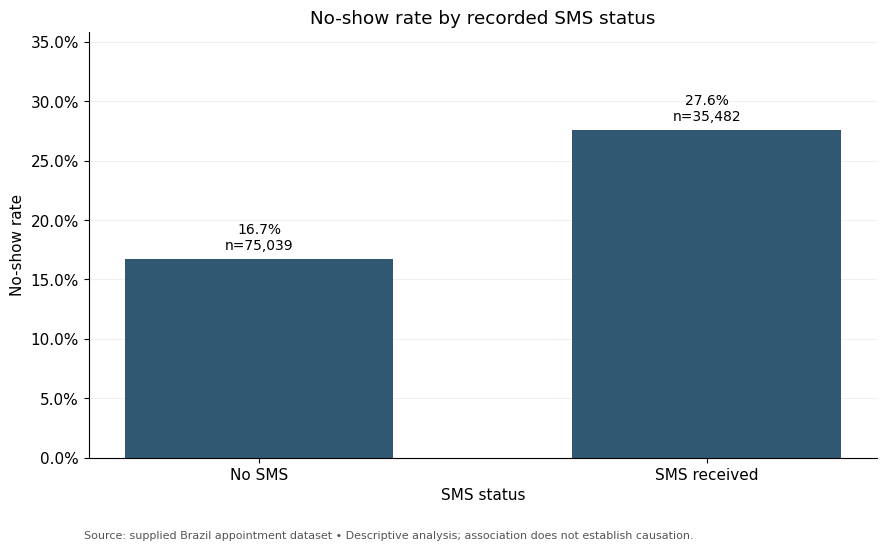

In [19]:
make_bar_plot(sms['no_show_rate'], 'No-show rate by recorded SMS status', 'SMS status', 'No-show rate', percent=True, filename='sms_no_show_rate.png', counts=sms['appointments'])


Observation: The no-show rate was approximately 16.7% among appointments where an SMS reminder was not received, compared with approximately 27.6% among appointments where an SMS reminder was received. Therefore, appointments with an SMS reminder had a higher observed no-show rate in this dataset. However, this is an association only and does not mean that receiving an SMS caused patients to miss their appointments.

#### Research Question 2: How does patient age relate to the likelihood of missing an appointment?

In [20]:
# Explore the distribution of patient ages
df['age'].describe()

Out[20]: 
count    110521.000000
mean         37.089386
std          23.109885
min           0.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: age, dtype: float64


count    110521.000000
mean         37.089386
std          23.109885
min           0.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: age, dtype: float64

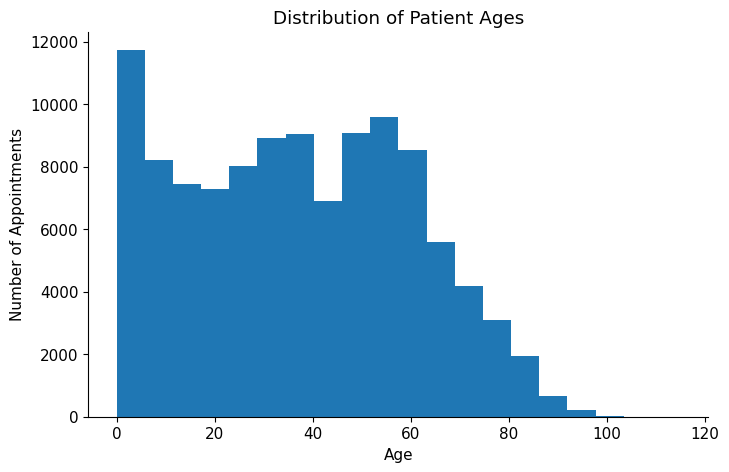

In [21]:
# Plot the distribution of patient ages
df['age'].plot(
    kind='hist',
    bins=20,
    figsize=(8, 5)
)

plt.title('Distribution of Patient Ages')
plt.xlabel('Age')
plt.ylabel('Number of Appointments')
plt.show()

In [22]:
age = df.groupby('missed')['age'].agg(appointments='size', mean_age='mean', median_age='median')
age.index = age.index.map({0: 'Attended', 1: 'Missed'})
age.to_csv(RESULTS / 'age_summary.csv')
display(age)


,appointments,mean_age,median_age
missed,,,
Attended,88207,37.790504,38.0
Missed,22314,34.317872,33.0


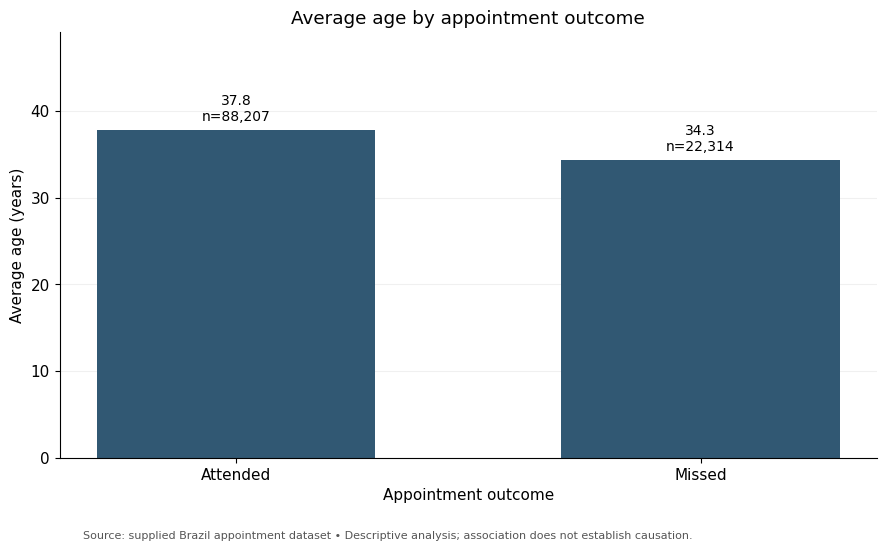

In [23]:
make_bar_plot(age['mean_age'], 'Average age by appointment outcome', 'Appointment outcome', 'Average age (years)', filename='average_age_by_outcome.png', counts=age['appointments'])


The appointment-weighted average age is approximately 37.8 years for attended appointments and 34.3 years for missed appointments. These averages describe the two outcome groups; they do not estimate a no-show probability for each age or demonstrate a monotonic age relationship. A patient with several appointments contributes several records.

### Research question 3: How does scheduling lead time relate to the no-show rate?


In [24]:
waiting_by_no_show = df.groupby('missed')['waiting_days'].mean().rename(index={0:'Attended', 1:'Missed'})
waiting_by_no_show


Out[24]: 
missed
Attended     8.754759
Missed      15.835484
Name: waiting_days, dtype: float64


missed
Attended     8.754759
Missed      15.835484
Name: waiting_days, dtype: float64

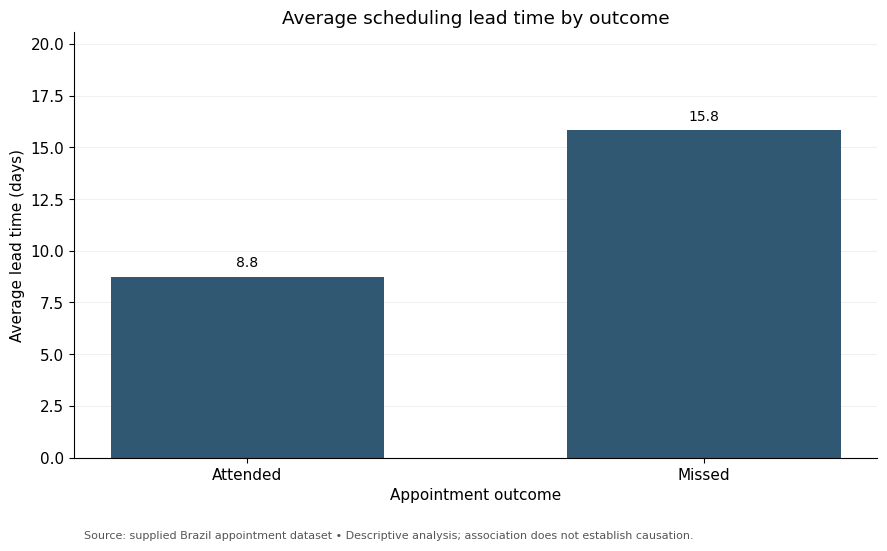

In [25]:
make_bar_plot(waiting_by_no_show, 'Average scheduling lead time by outcome', 'Appointment outcome', 'Average lead time (days)')


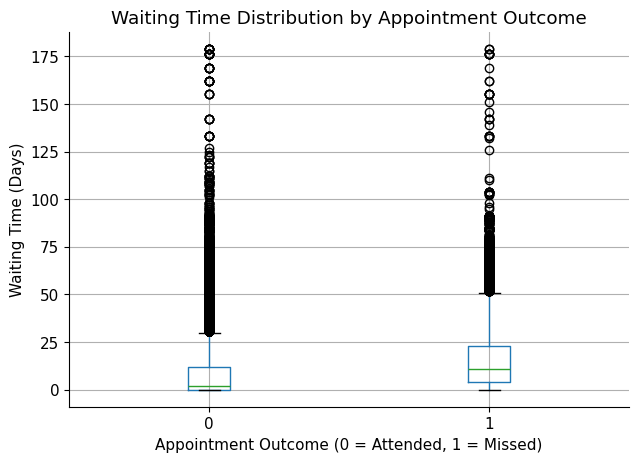

In [26]:
# Compare the distribution of waiting times by appointment outcome
df.boxplot(
    column='waiting_days',
    by='missed',
    figsize=(7, 5)
)

plt.title('Waiting Time Distribution by Appointment Outcome')
plt.suptitle('')
plt.xlabel('Appointment Outcome (0 = Attended, 1 = Missed)')
plt.ylabel('Waiting Time (Days)')
plt.show()

Observation: The box plot provides additional detail about the distribution of waiting times for attended and missed appointments. Missed appointments generally had longer waiting times, and both groups included appointments with unusually long waits. This supports the earlier finding that longer waiting times are associated with a higher likelihood of a no-show, while also showing substantial variation within each appointment outcome group.

In [27]:
df['waiting_group'] = pd.cut(df['waiting_days'], bins=[-1, 0, 7, 14, 30, np.inf],
    labels=['Same day', '1–7 days', '8–14 days', '15–30 days', '31+ days'])
waiting = df.groupby('waiting_group', observed=False)['missed'].agg(appointments='size', missed='sum', no_show_rate='mean')
assert waiting['appointments'].sum() == len(df)
waiting.to_csv(RESULTS / 'waiting_time_summary.csv')
display(waiting)


,appointments,missed,no_show_rate
waiting_group,,,
Same day,38562,1792,0.046471
1–7 days,32185,7772,0.241479
8–14 days,12025,3664,0.304699
15–30 days,17371,5661,0.325888
31+ days,10378,3425,0.330025


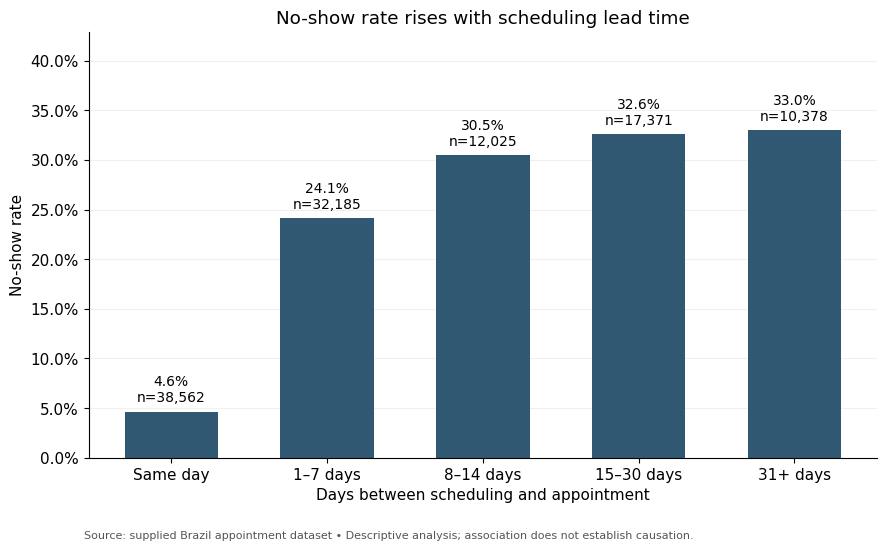

In [28]:
make_bar_plot(waiting['no_show_rate'], 'No-show rate rises with scheduling lead time', 'Days between scheduling and appointment', 'No-show rate', percent=True, filename='no_show_rate_by_waiting_time.png', counts=waiting['appointments'])


## Conclusions

- **SMS status:** Recorded SMS recipients had a 27.6% no-show rate versus 16.7% without SMS. This comparison does not measure the causal effect of reminders; reminder selection and lead time could differ across groups.
- **Age:** Attended appointments had a mean patient age of 37.8 years, compared with 34.3 for missed appointments. Group averages do not establish age-specific risk.
- **Scheduling lead time:** No-show rates rose from 4.6% for same-day appointments to 24.1%, 30.5%, 32.6%, and 33.0% across successively longer waiting categories. Mean lead time was 8.8 days for attended appointments and 15.8 for missed appointments.

### Operational questions to investigate

Could easier confirmation and rescheduling help patients with appointments booked far ahead? Does the SMS association persist when comparing appointments with similar lead times? These are hypotheses for follow-up analysis and prospective evaluation; no intervention or improvement was measured in this project.

### Limitations

This is observational, historical appointment-level data. Repeat appointments from the same patient may be related, so independence cannot be assumed for future statistical inference. SMS timing and selection criteria are unavailable. Appointment purpose, transport access, and other unmeasured factors could influence attendance. Results may not generalize to another healthcare setting.

The comparison is descriptive: no statistical significance, predictive performance, causal effect, or operational impact is claimed. Regression could examine adjusted associations, but would not by itself resolve unmeasured confounding or establish causality.

### Further work

Compare SMS groups within lead-time categories; examine age-specific no-show rates and uncertainty; assess repeat-patient patterns. Any predictive extension should split data appropriately by patient and time to avoid leakage.

### Provenance

Based on the user's original Udacity notebook and uploaded `noshowappointments-kagglev2-may-2016.csv`. The execution below records the exact CSV checksum and package versions. No external data was substituted.


In [29]:
import sys
import matplotlib
provenance = {'dataset': DATA.name, 'sha256': hashlib.sha256(DATA.read_bytes()).hexdigest(),
    'original_rows': raw_rows, 'cleaned_rows': len(df),
    'python': sys.version.split()[0], 'pandas': pd.__version__,
    'numpy': np.__version__, 'matplotlib': matplotlib.__version__}
(RESULTS / 'provenance.json').write_text(json.dumps(provenance, indent=2))
provenance


Out[29]: 
{'dataset': 'noshowappointments-kagglev2-may-2016.csv',
 'sha256': '9132d3e7d0246617df9041d3764f20ad6f08e7b0d9f0997fa254fc5e52eda27d',
 'original_rows': 110527,
 'cleaned_rows': 110521,
 'python': '3.12.14',
 'pandas': '2.2.3',
 'numpy': '2.3.5',
 'matplotlib': '3.10.8'}


{'dataset': 'noshowappointments-kagglev2-may-2016.csv',
 'sha256': '9132d3e7d0246617df9041d3764f20ad6f08e7b0d9f0997fa254fc5e52eda27d',
 'original_rows': 110527,
 'cleaned_rows': 110521,
 'python': '3.12.14',
 'pandas': '2.2.3',
 'numpy': '2.3.5',
 'matplotlib': '3.10.8'}